# Laboratorio 1 - Series de Tiempo

## Universidad del Valle de Guatemala

### CC3084 - Data Science

**Integrantes:**

- Osman de León
- Milton Polanco

---

## Objetivo

Realizar un análisis exploratorio del conjunto de datos de ingreso de viajeros internacionales a Guatemala y construir series de tiempo mensuales para su posterior modelado y predicción.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [16]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")

In [17]:
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


     -------------------------------------- 12.6/12.6 MB 668.3 kB/s eta 0:00:00
     -------------------------------------- 10.0/10.0 MB 394.6 kB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 327.9 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
     ------------------------------------ 348.2/348.2 kB 245.8 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.4/2.4 MB 245.4 kB/s eta 0:00:00
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
  Using cached packaging-26.2-py3-none-any.whl (100 kB)
     ---------------------------------------- 7.2/7.2 MB 484.1 kB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: tzdata
    F

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Emadlg\\Desktop\\UVG\\Cuarto Año\\Primer Ciclo\\Inteligencia Artificial\\proyectoIA\\venv\\Lib\\site-packages\\~il\\_imaging.cp311-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
df.shape

(161036, 13)

In [19]:
df.columns

Index(['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región',
       'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia',
       'Tipo de Viajero', 'Viajero'],
      dtype='str')

In [20]:
df.describe()

,Año,Mes cod,Viajero
count,161036.000000,161036.000000,161036.000000
mean,2016.017543,6.416075,324.697193
std,4.552887,3.531936,2387.745140
min,2009.000000,1.000000,0.000000
25%,2012.000000,3.000000,2.000000
50%,2016.000000,6.000000,7.000000
75%,2019.000000,10.000000,38.891667
max,2026.000000,12.000000,92336.035067


In [12]:
df.describe(include="object")

,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero
count,161036,161036,161036,161036,161036,161036,161036,161036,161036,161036
unique,12,3,22,235,17,11,26,8,33,4
top,Ene,Terrestre,01 La Aurora,Guatemala,EUROPA,Europa,AMÉRICA CENTRAL,08 OTROS,Europa,Turista
freq,14726,125873,21424,6319,32331,54640,31362,73173,46761,117912


In [21]:
df.isna().sum()

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df["Fecha"] = pd.to_datetime(
    dict(
        year=df["Año"],
        month=df["Mes cod"],
        day=1
    )
)

df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


In [26]:
# Verificar si existen valores faltantes

df.isnull().sum()

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
Fecha                    0
dtype: int64

In [38]:
df_turismo["Tipo de Viajero"].value_counts()

Tipo de Viajero
Turista          117912
Excursionista     19730
Name: count, dtype: int64

In [39]:
serie_total = (
    df_turismo
    .groupby("Fecha")["Viajero"]
    .sum()
)

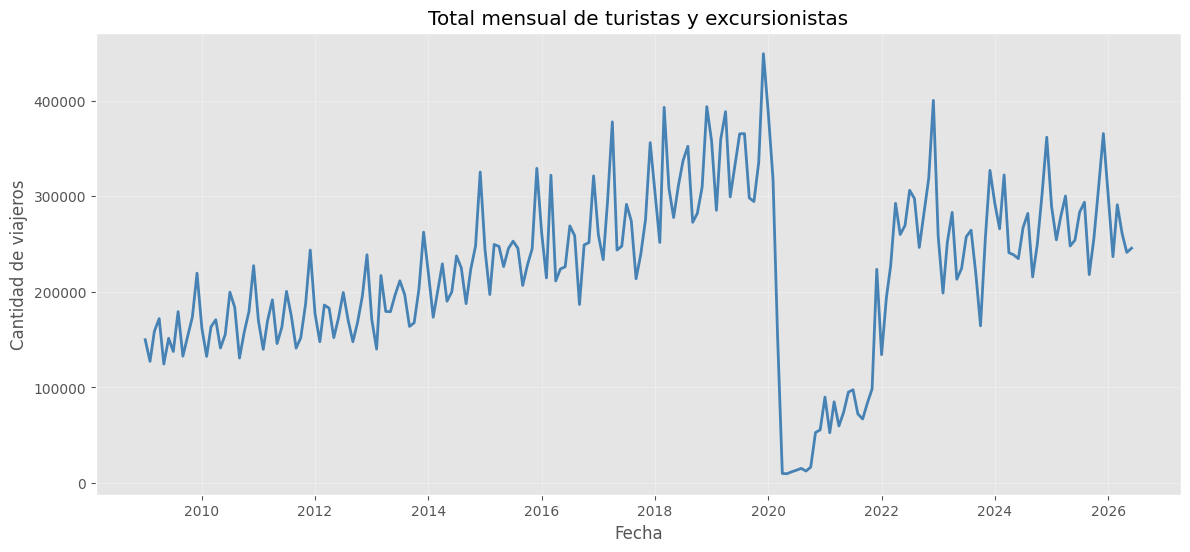

In [43]:
plt.figure(figsize=(14,6))

plt.plot(
    serie_total.index,
    serie_total.values,
    color="steelblue",
    linewidth=2
)

plt.title("Total mensual de turistas y excursionistas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(alpha=0.3)

plt.show()

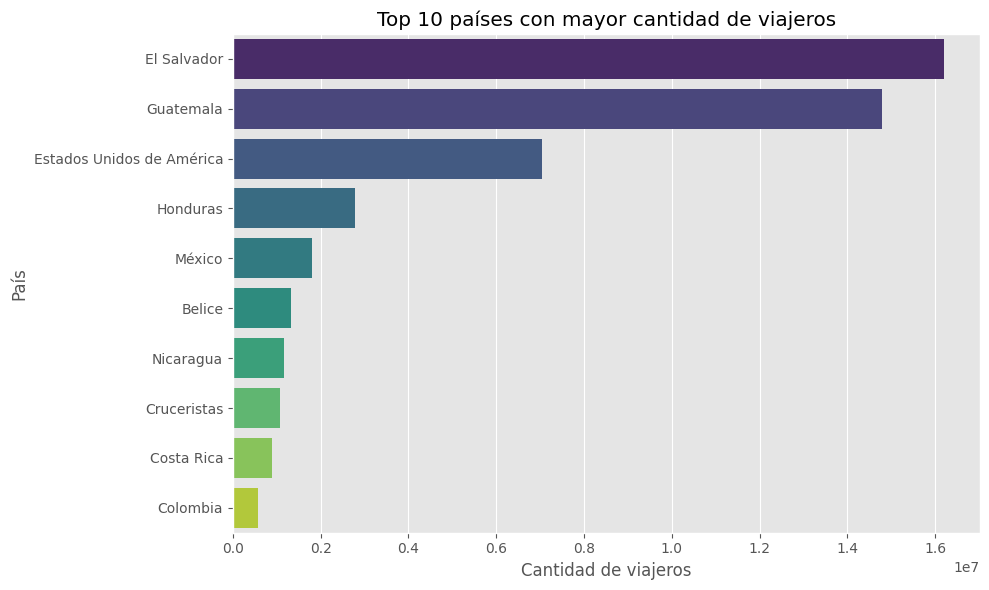

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_paises.head(10),
    x="Viajero",
    y="País",
    hue="País",
    palette="viridis",
    legend=False
)

plt.title("Top 10 países con mayor cantidad de viajeros")
plt.xlabel("Cantidad de viajeros")
plt.ylabel("País")

plt.tight_layout()
plt.show()

In [54]:
top_regiones = (
    df_turismo
    .groupby("Región dos", as_index=False)["Viajero"]
    .sum()
    .sort_values("Viajero", ascending=False)
)

top_regiones

,Región dos,Viajero
1,América Del Centro,3.328393e+07
2,América Del Norte,9.160810e+06
5,Europa,2.149271e+06
3,América Del Sur y el Caribe,1.413590e+06
4,Asia,4.103335e+05
6,Oceanía,1.355054e+05
7,Oriente Medio,1.337352e+05
8,Otros Paises Del Mundo,2.391430e+04
0,0,8.210000e+02


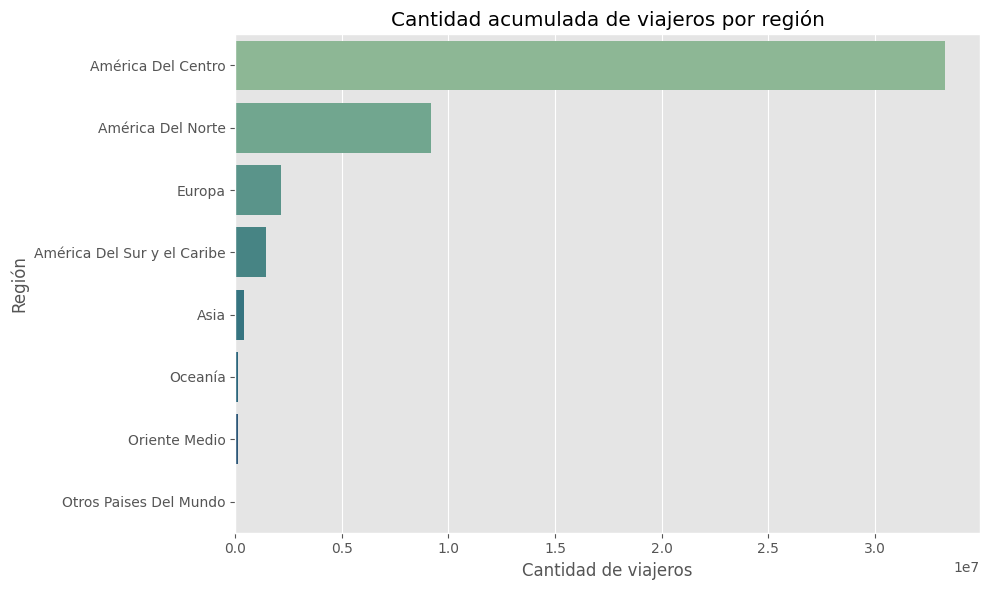

In [99]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_regiones,
    x="Viajero",
    y="Región dos",
    hue="Región dos",
    palette="crest",
    legend=False
)

plt.title("Cantidad acumulada de viajeros por región")
plt.xlabel("Cantidad de viajeros")
plt.ylabel("Región")

plt.tight_layout()
plt.show()

In [46]:
vias = (
    df_turismo
    .groupby("Vía", as_index=False)["Viajero"]
    .sum()
    .sort_values("Viajero", ascending=False)
)

vias

,Vía,Viajero
2,Terrestre,2.759225e+07
0,Aérea,1.901942e+07
1,Marítima,1.002410e+05


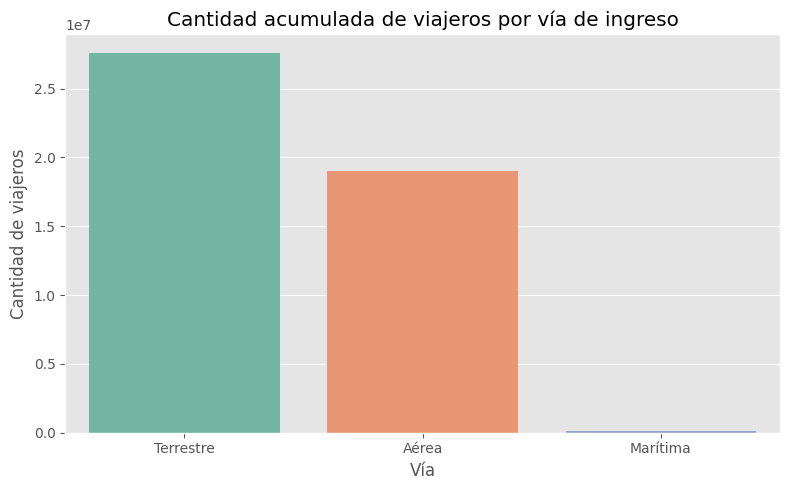

In [100]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=vias,
    x="Vía",
    y="Viajero",
    hue="Vía",
    palette="Set2",
    legend=False
)

plt.title("Cantidad acumulada de viajeros por vía de ingreso")
plt.xlabel("Vía")
plt.ylabel("Cantidad de viajeros")

plt.tight_layout()
plt.show()

In [47]:
fronteras = (
    df_turismo
    .groupby("Frontera", as_index=False)["Viajero"]
    .sum()
    .sort_values("Viajero", ascending=False)
)

fronteras.head(10)

,Frontera,Viajero
0,01 La Aurora,1.898998e+07
6,07 Valle Nuevo,1.014305e+07
8,09 San Cristóbal,4.183632e+06
7,08 Pedro de Alvarado,3.764229e+06
9,10 La Ermita (Nueva Anguiatú),2.587072e+06
19,20 Melchor de Mencos,1.782864e+06
12,13 El Cinchado / El Corinto,1.213485e+06
10,11 Agua Caliente,9.224195e+05
11,12 El Florido,9.103735e+05
14,15 El Carmen,8.526631e+05


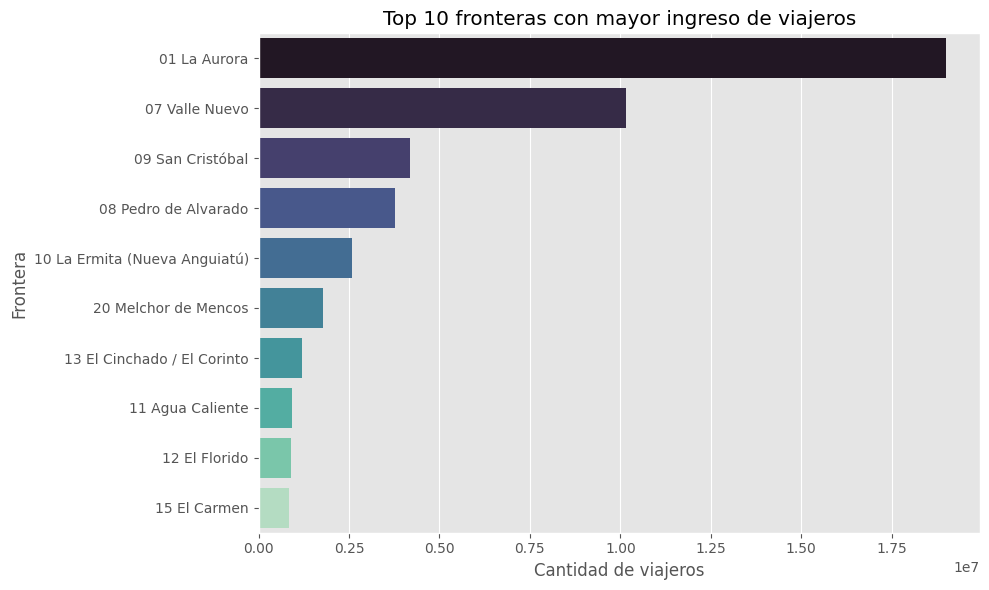

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=fronteras.head(10),
    x="Viajero",
    y="Frontera",
    hue="Frontera",
    palette="mako",
    legend=False
)

plt.title("Top 10 fronteras con mayor ingreso de viajeros")
plt.xlabel("Cantidad de viajeros")
plt.ylabel("Frontera")

plt.tight_layout()
plt.show()

La Aurora constituye la principal frontera de ingreso de viajeros internacionales, seguida por Valle Nuevo y San Cristóbal. Estas fronteras concentran una proporción importante del flujo total registrado durante el período de estudio.

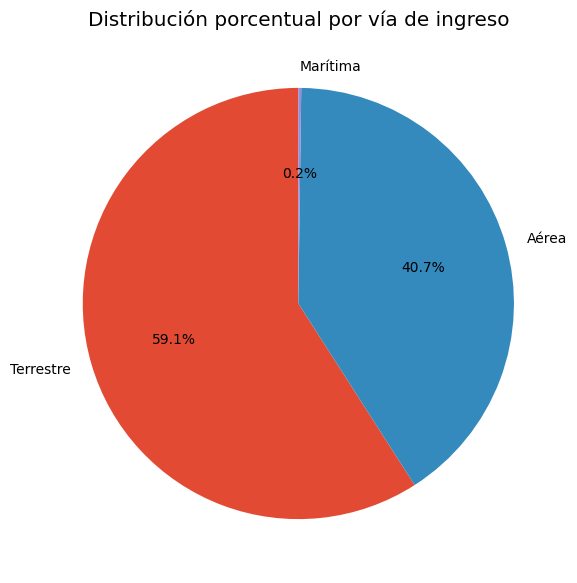

In [64]:
plt.figure(figsize=(7,7))

plt.pie(
    vias["Viajero"],
    labels=vias["Vía"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución porcentual por vía de ingreso")

plt.show()

In [48]:
serie_aerea = (
    df_turismo[
        df_turismo["Vía"] == "Aérea"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
)

serie_aerea.head()

Fecha
2009-01-01    81693.0
2009-02-01    70099.0
2009-03-01    84494.0
2009-04-01    80618.0
2009-05-01    64621.0
Name: Viajero, dtype: float64

In [49]:
serie_terrestre = (
    df_turismo[
        df_turismo["Vía"] == "Terrestre"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
)

In [50]:
serie_maritima = (
    df_turismo[
        df_turismo["Vía"] == "Marítima"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
)

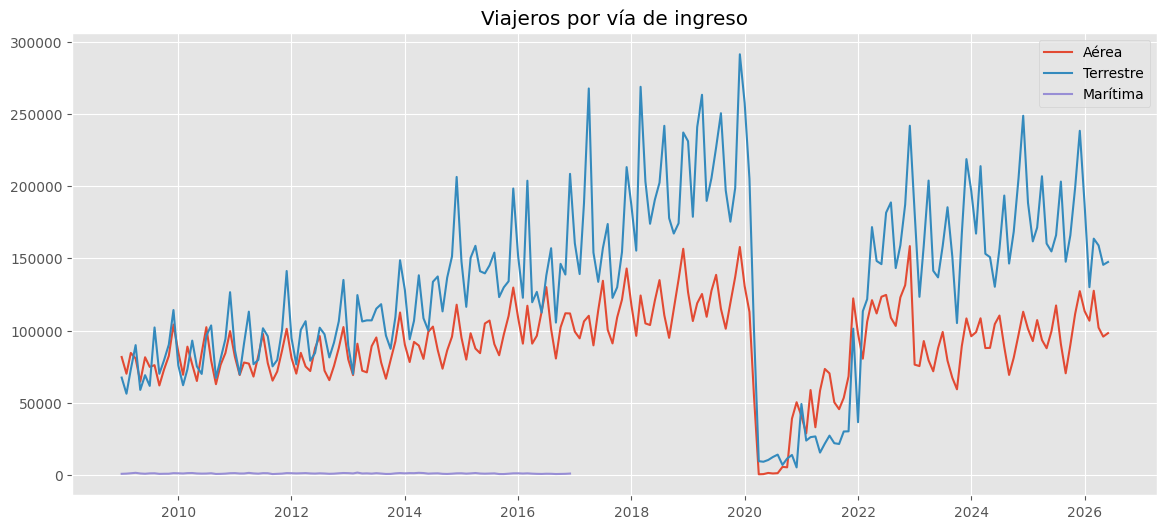

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    serie_aerea,
    label="Aérea"
)

plt.plot(
    serie_terrestre,
    label="Terrestre"
)

plt.plot(
    serie_maritima,
    label="Marítima"
)

plt.legend()

plt.title("Viajeros por vía de ingreso")

plt.show()

La vía terrestre representa la principal forma de ingreso de turistas y excursionistas, seguida por la vía aérea. La vía marítima presenta una participación considerablemente menor y únicamente registra información hasta diciembre de 2016, por lo que no será utilizada para el análisis de series de tiempo.

# 2. Preparación de las series de tiempo

De acuerdo con las instrucciones del laboratorio, la serie se divide en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%), respetando el orden cronológico de las observaciones.

In [65]:
# División 70% entrenamiento - 30% prueba

n = len(serie_total)

train_size = int(n * 0.70)

train = serie_total.iloc[:train_size]

test = serie_total.iloc[train_size:]

print("Entrenamiento:", len(train))
print("Prueba:", len(test))

Entrenamiento: 147
Prueba: 63


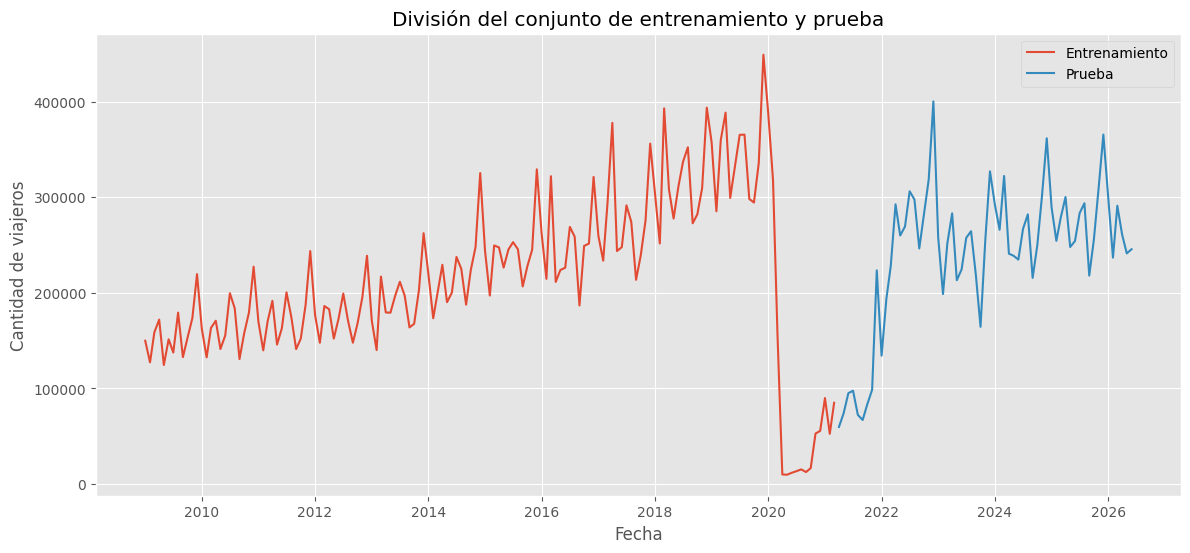

In [66]:
plt.figure(figsize=(14,6))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba")

plt.title("División del conjunto de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.legend()

plt.show()

In [68]:
print(f"Inicio: {train.index.min().strftime('%B %Y')}")
print(f"Fin: {train.index.max().strftime('%B %Y')}")
print(f"Frecuencia: {pd.infer_freq(train.index)}")

Inicio: January 2009
Fin: March 2021
Frecuencia: MS


## 2.1 Serie Total (Entrenamiento)

### 4.b Gráfico de la serie1

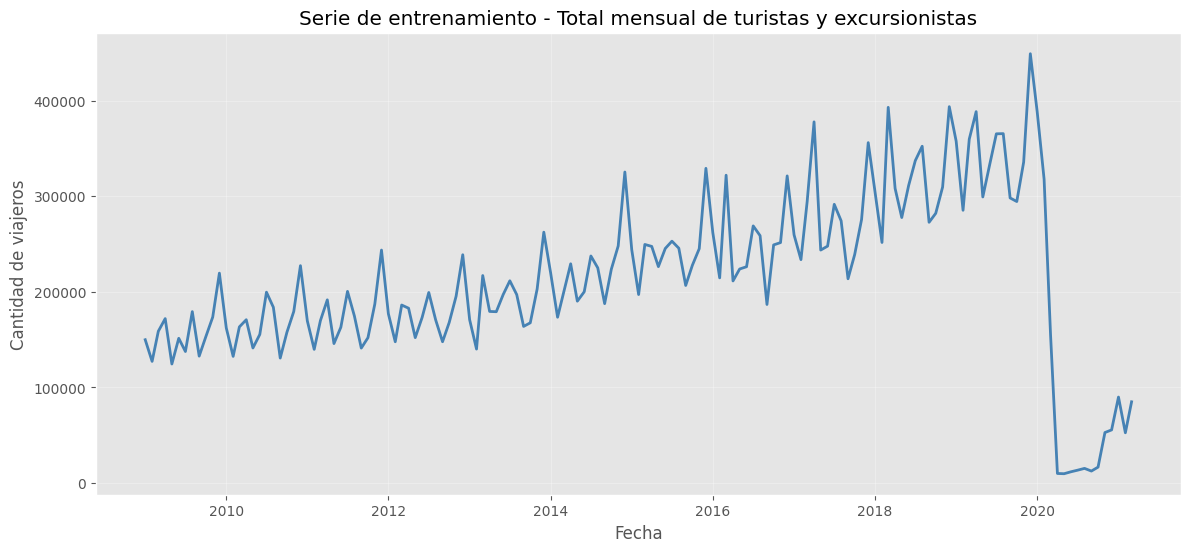

In [69]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train.values,
    color="steelblue",
    linewidth=2
)

plt.title("Serie de entrenamiento - Total mensual de turistas y excursionistas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(alpha=0.3)

plt.show()

### Interpretación

La serie presenta una tendencia creciente entre 2009 y 2019. Además, se observan patrones repetitivos en determinados meses del año, lo que sugiere la presencia de estacionalidad.

Durante 2020 ocurre una caída abrupta asociada a la pandemia de COVID-19. A partir de ese momento comienza una recuperación gradual, aunque el comportamiento continúa siendo diferente al observado antes de la pandemia.

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

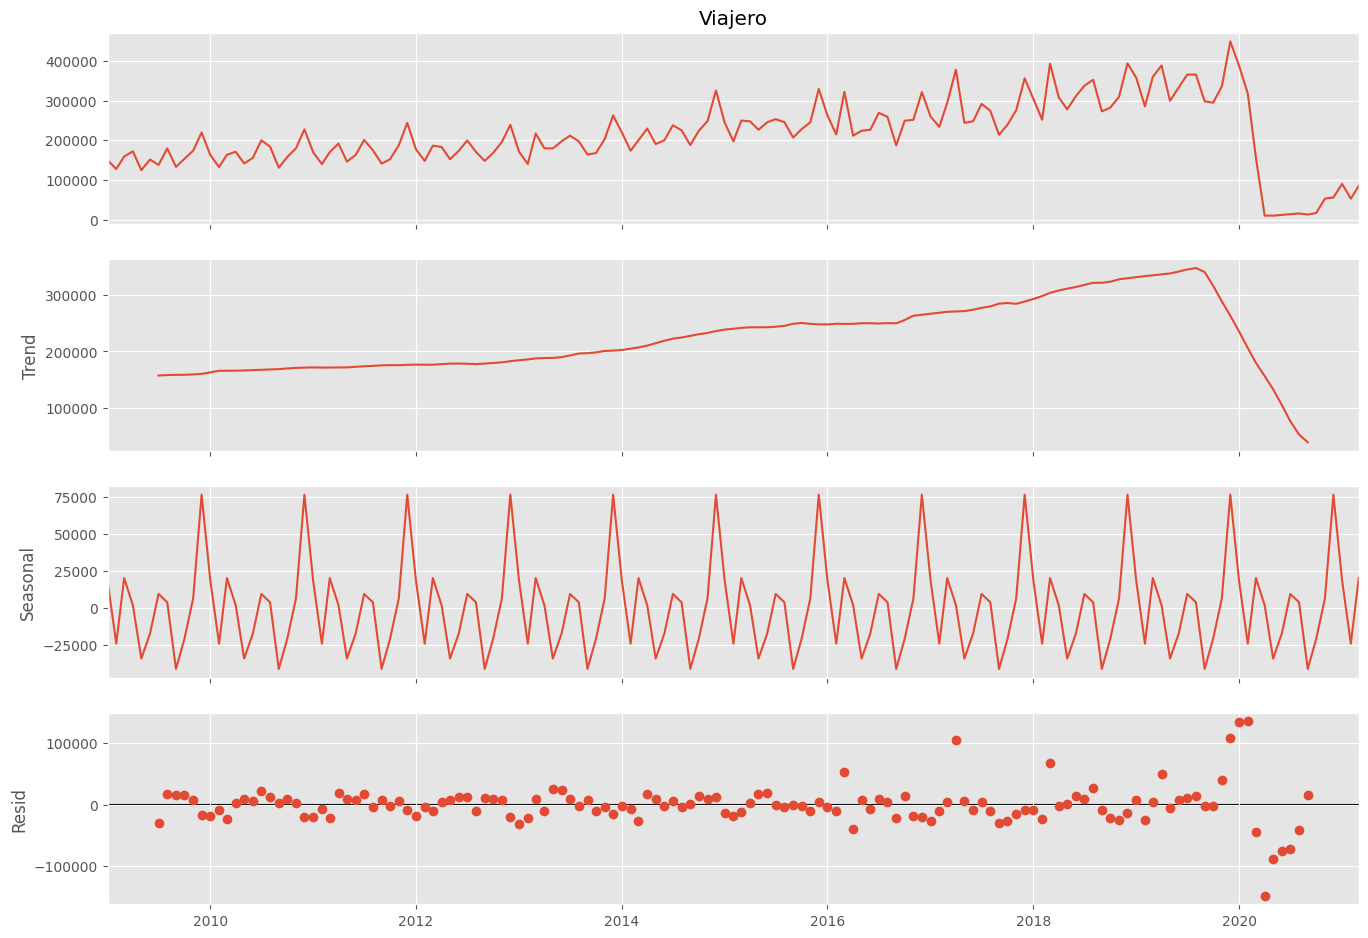

In [71]:
descomposicion = seasonal_decompose(
    train,
    model="additive",
    period=12
)

fig = descomposicion.plot()
fig.set_size_inches(14,10)

plt.show()

### Interpretación de la descomposición

La descomposición de la serie permite identificar claramente sus cuatro componentes:

- **Serie original:** Se observa una tendencia creciente desde 2009 hasta antes de la pandemia, seguida por una caída abrupta durante 2020.
- **Tendencia:** El componente de tendencia muestra un crecimiento sostenido del número de viajeros durante gran parte del período de entrenamiento. La disminución observada al final corresponde al impacto de la pandemia.
- **Estacionalidad:** Existe un patrón estacional marcado que se repite aproximadamente cada 12 meses, indicando que existen meses con mayor y menor afluencia de turistas de forma consistente.
- **Residuos:** Los residuos se distribuyen alrededor de cero, aunque presentan una mayor dispersión hacia el final de la serie debido al efecto extraordinario de la pandemia.

### ¿Es necesario transformar la serie?

La serie presenta una ligera variación en la varianza a lo largo del tiempo y un cambio abrupto durante la pandemia. Sin embargo, para el avance del laboratorio se continuará inicialmente con la serie original, ya que primero se evaluará formalmente la estacionariedad mediante la función de autocorrelación y la prueba de Dickey-Fuller Aumentada. En caso de ser necesario, posteriormente podrá aplicarse una transformación logarítmica o Box-Cox.

In [72]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1000x500 with 0 Axes>

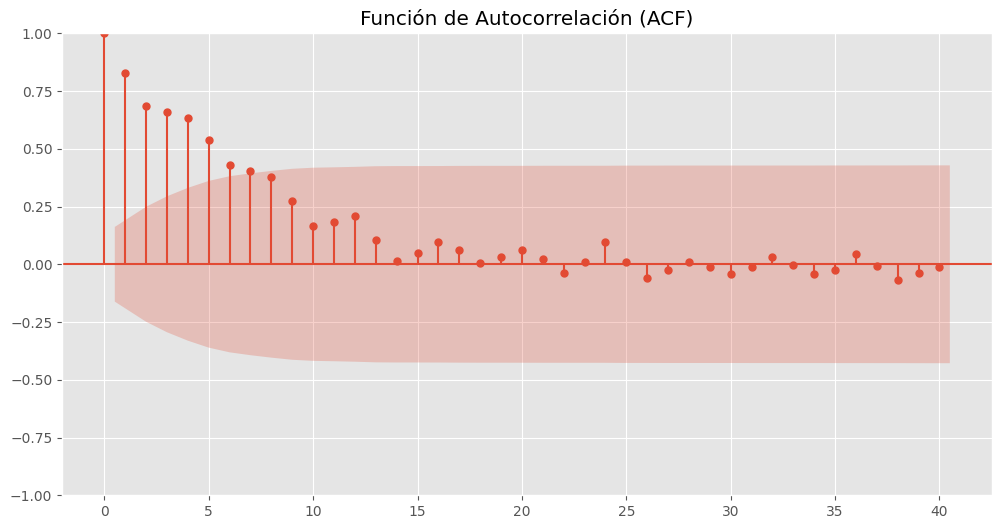

In [73]:
plt.figure(figsize=(10,5))

plot_acf(train, lags=40)

plt.title("Función de Autocorrelación (ACF)")

plt.show()

### Función de Autocorrelación (ACF)

La función de autocorrelación muestra valores elevados en los primeros rezagos y un decrecimiento gradual conforme aumenta el número de rezagos. Este comportamiento indica una fuerte dependencia temporal entre las observaciones y sugiere que la serie no es estacionaria en media.

In [74]:
from statsmodels.tsa.stattools import adfuller

In [75]:
resultado = adfuller(train)

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print()

print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.3643663206006877
p-value: 0.15204729499110786

Valores críticos:
1%: -3.480500383888377
5%: -2.8835279559405045
10%: -2.578495716547007


### Prueba Dickey-Fuller Aumentada

La prueba Dickey-Fuller Aumentada obtuvo un valor p de 0.152, superior al nivel de significancia de 0.05. Por lo tanto, no se rechaza la hipótesis nula de presencia de raíz unitaria.

En consecuencia, la serie no es estacionaria en media y será necesario aplicar diferenciación antes de ajustar modelos ARIMA.

In [76]:
train_diff = train.diff().dropna()

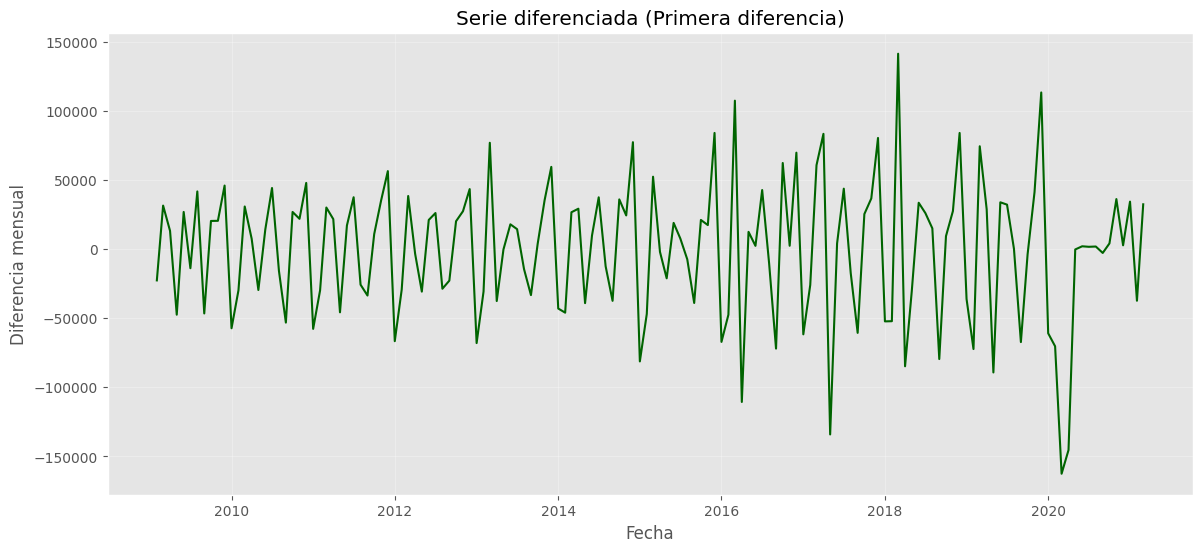

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    train_diff,
    color="darkgreen"
)

plt.title("Serie diferenciada (Primera diferencia)")
plt.xlabel("Fecha")
plt.ylabel("Diferencia mensual")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x500 with 0 Axes>

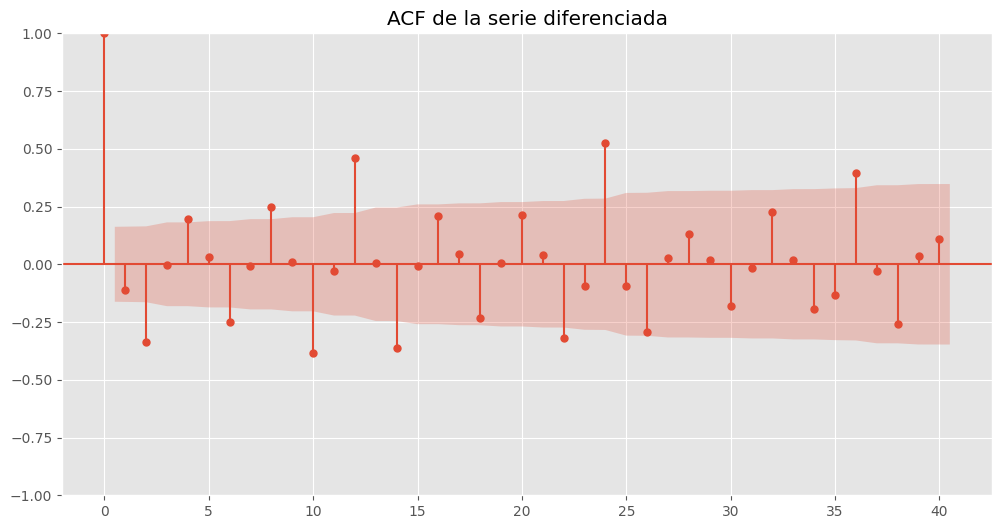

In [78]:
plt.figure(figsize=(10,5))

plot_acf(train_diff, lags=40)

plt.title("ACF de la serie diferenciada")

plt.show()

### Función de Autocorrelación (ACF)

La serie original presentó una autocorrelación elevada en los primeros rezagos y una disminución gradual, indicando que no era estacionaria.

Después de aplicar una primera diferenciación, la autocorrelación disminuye considerablemente y la mayoría de los rezagos se encuentran dentro de los intervalos de confianza, lo que indica una mejora en la estacionariedad de la serie.

In [79]:
resultado_diff = adfuller(train_diff)

print("ADF Statistic:", resultado_diff[0])
print("p-value:", resultado_diff[1])

print()

for key, value in resultado_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.987483779281721
p-value: 0.03607990560556653

1%: -3.4808880719210005
5%: -2.8836966192225284
10%: -2.5785857598714417


### Prueba Dickey-Fuller Aumentada

La prueba Dickey-Fuller aplicada a la serie original produjo un valor p de 0.152, por lo que no fue posible rechazar la hipótesis nula de presencia de raíz unitaria.

Posteriormente se aplicó una primera diferenciación a la serie. La prueba Dickey-Fuller sobre la serie diferenciada obtuvo un valor p de 0.036, inferior al nivel de significancia de 0.05, indicando que la serie diferenciada puede considerarse estacionaria.

Por lo tanto, una diferenciación fue suficiente para estabilizar la media de la serie.

## Serie 2: América del Centro

In [81]:
serie_centro = (
    df_turismo[
        df_turismo["Región dos"] == "América Del Centro"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
)

In [82]:
n = len(serie_centro)

train_size = int(n * 0.70)

train_centro = serie_centro.iloc[:train_size]

test_centro = serie_centro.iloc[train_size:]

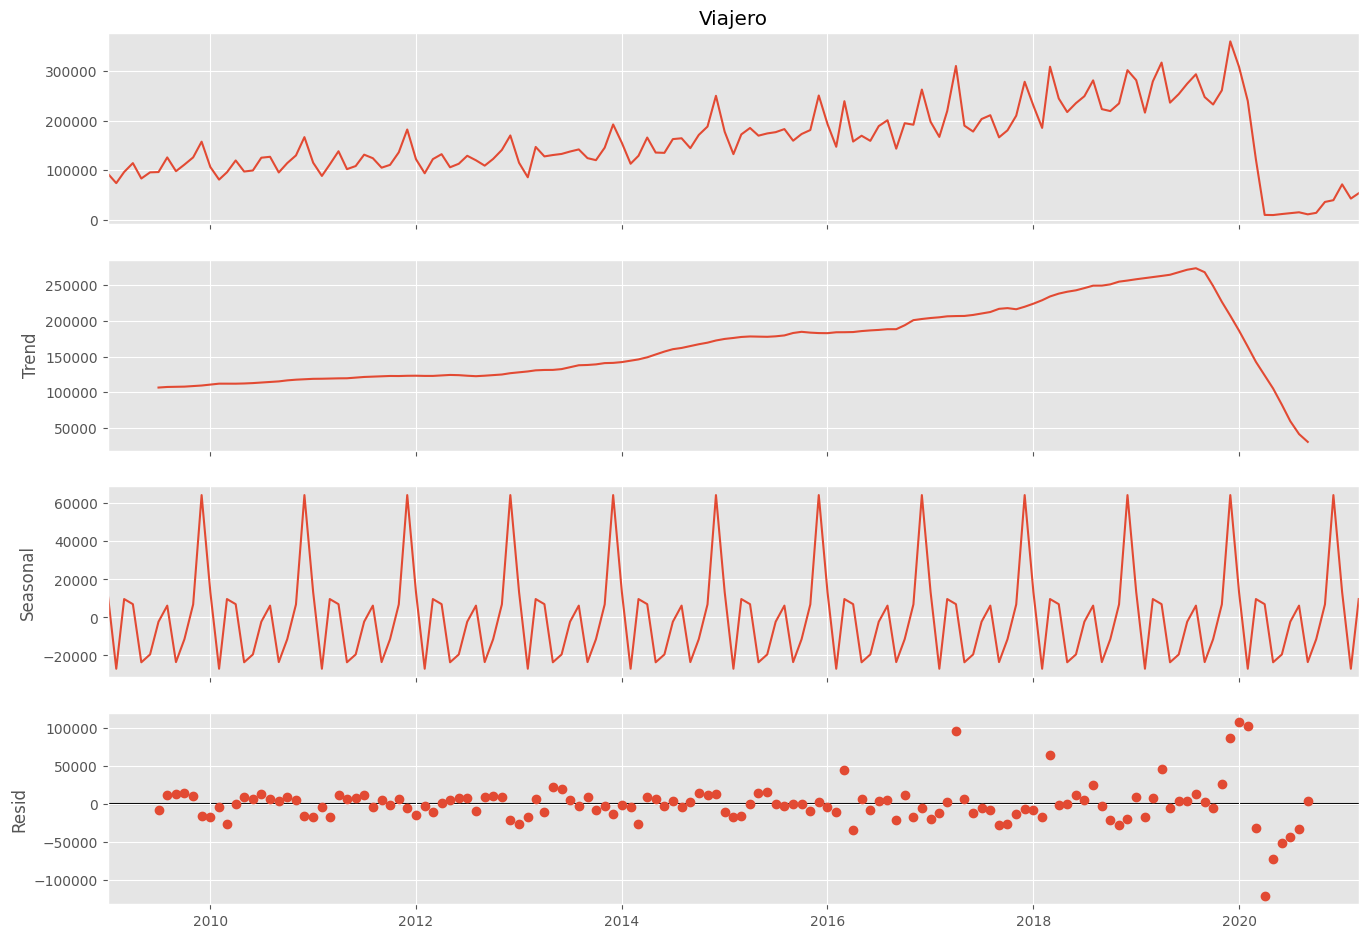

In [101]:
descomp_centro = seasonal_decompose(
    train_centro,
    model="additive",
    period=12
)

fig = descomp_centro.plot()
fig.set_size_inches(14,10)

plt.show()

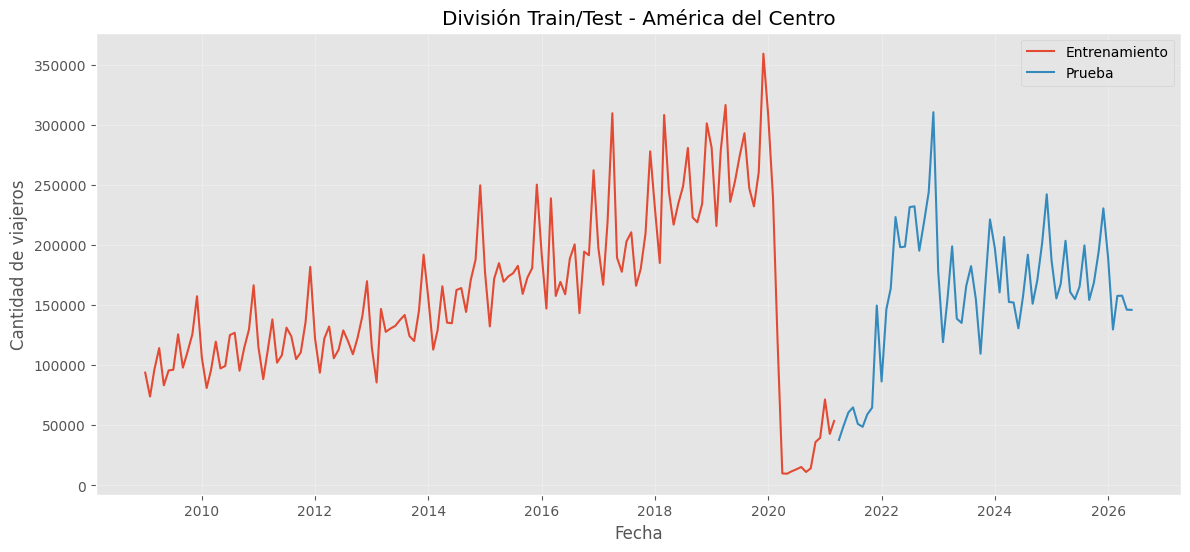

In [83]:
plt.figure(figsize=(14,6))

plt.plot(train_centro, label="Entrenamiento")
plt.plot(test_centro, label="Prueba")

plt.title("División Train/Test - América del Centro")

plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretación

La descomposición de la serie permite identificar claramente sus componentes principales.

- **Tendencia:** Se observa una tendencia creciente desde 2009 hasta principios de 2020, indicando un incremento sostenido del ingreso de viajeros provenientes de América del Centro. La caída al final de la serie corresponde al impacto de la pandemia por COVID-19.

- **Estacionalidad:** La componente estacional presenta un patrón que se repite aproximadamente cada 12 meses, lo que evidencia un comportamiento estacional consistente durante todo el período analizado.

- **Residuos:** Los residuos se distribuyen alrededor de cero durante la mayor parte del período; sin embargo, presentan una mayor dispersión durante 2020 debido al comportamiento atípico provocado por la pandemia.

In [84]:
print("Inicio:", train_centro.index.min().strftime("%B %Y"))
print("Fin:", train_centro.index.max().strftime("%B %Y"))
print("Frecuencia:", pd.infer_freq(train_centro.index))

Inicio: January 2009
Fin: March 2021
Frecuencia: MS


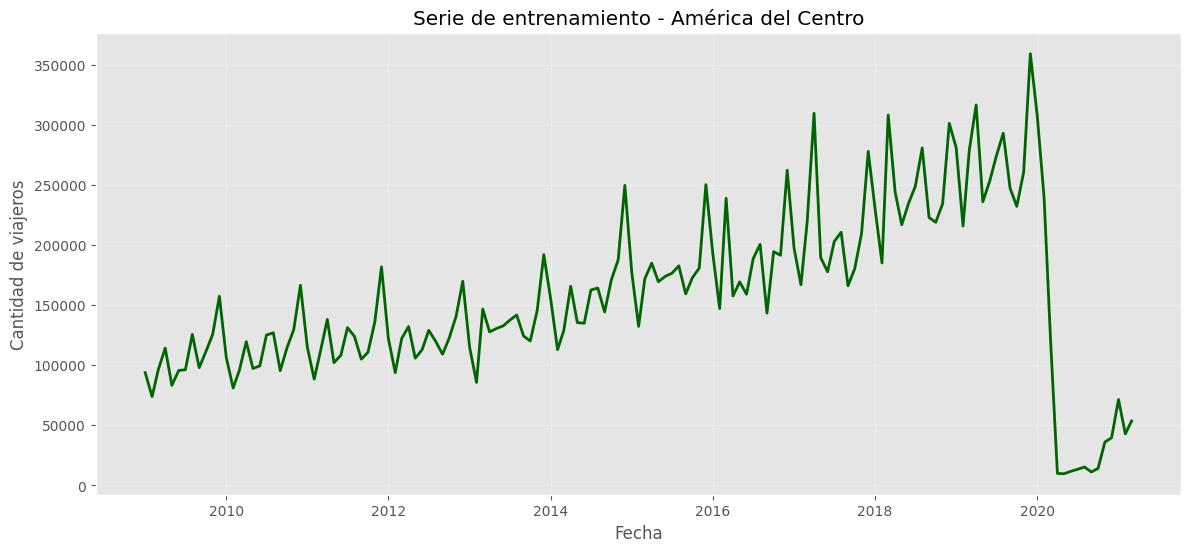

In [85]:
plt.figure(figsize=(14,6))

plt.plot(
    train_centro,
    color="darkgreen",
    linewidth=2
)

plt.title("Serie de entrenamiento - América del Centro")

plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x500 with 0 Axes>

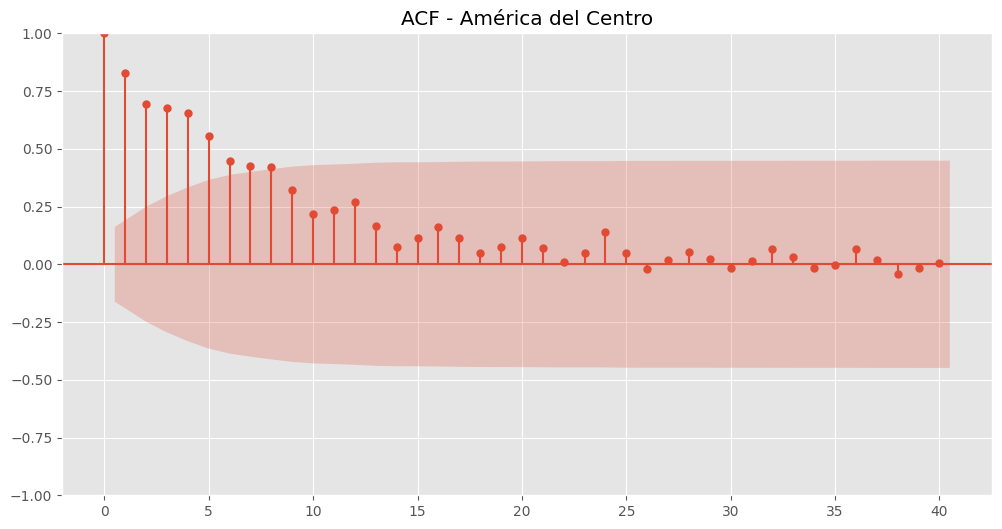

In [86]:
plt.figure(figsize=(10,5))

plot_acf(train_centro, lags=40)

plt.title("ACF - América del Centro")

plt.show()

In [89]:
resultado_centro = adfuller(train_centro)

print("ADF Statistic:", resultado_centro[0])
print("p-value:", resultado_centro[1])

print()

for key, value in resultado_centro[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.180555287207037
p-value: 0.2133783007378145

1%: -3.480500383888377
5%: -2.8835279559405045
10%: -2.578495716547007


In [91]:
train_centro_diff = train_centro.diff().dropna()

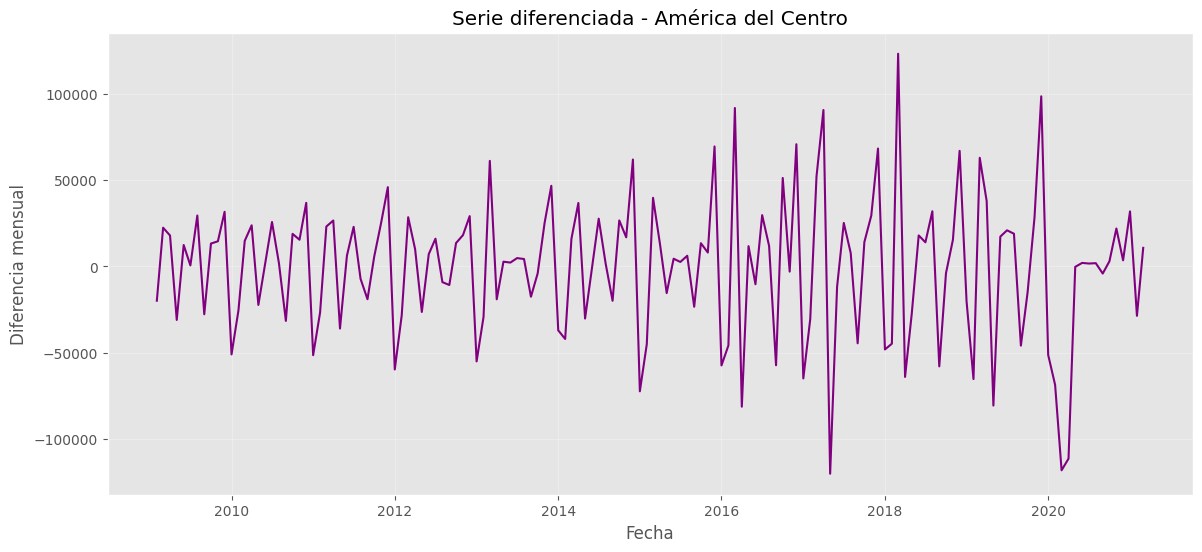

In [92]:
plt.figure(figsize=(14,6))

plt.plot(
    train_centro_diff,
    color="purple"
)

plt.title("Serie diferenciada - América del Centro")

plt.xlabel("Fecha")
plt.ylabel("Diferencia mensual")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x500 with 0 Axes>

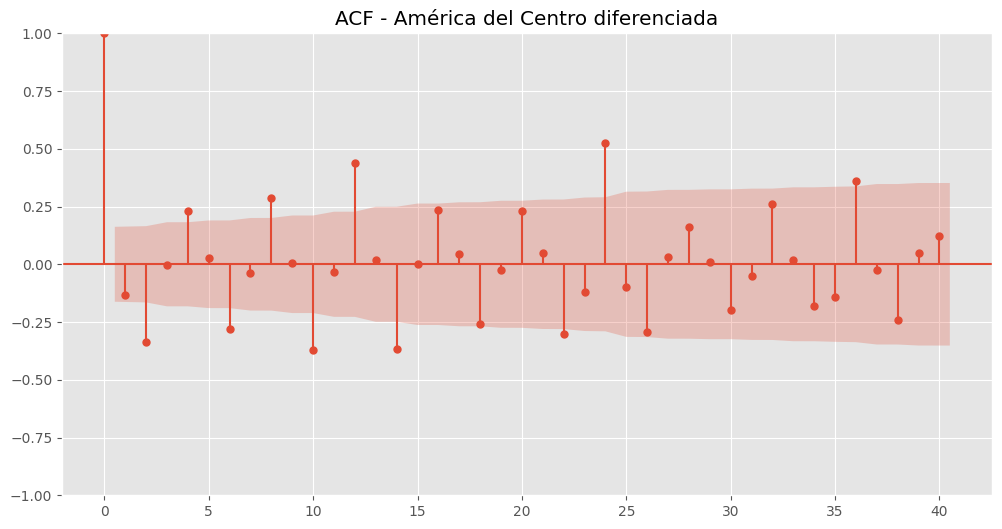

In [93]:
plt.figure(figsize=(10,5))

plot_acf(train_centro_diff, lags=40)

plt.title("ACF - América del Centro diferenciada")

plt.show()

In [94]:
resultado_centro_diff = adfuller(train_centro_diff)

print("ADF Statistic:", resultado_centro_diff[0])
print("p-value:", resultado_centro_diff[1])

print()

for key, value in resultado_centro_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.644628820546099
p-value: 0.08411965891744289

1%: -3.480500383888377
5%: -2.8835279559405045
10%: -2.578495716547007


In [95]:
train_centro_diff2 = train_centro_diff.diff().dropna()

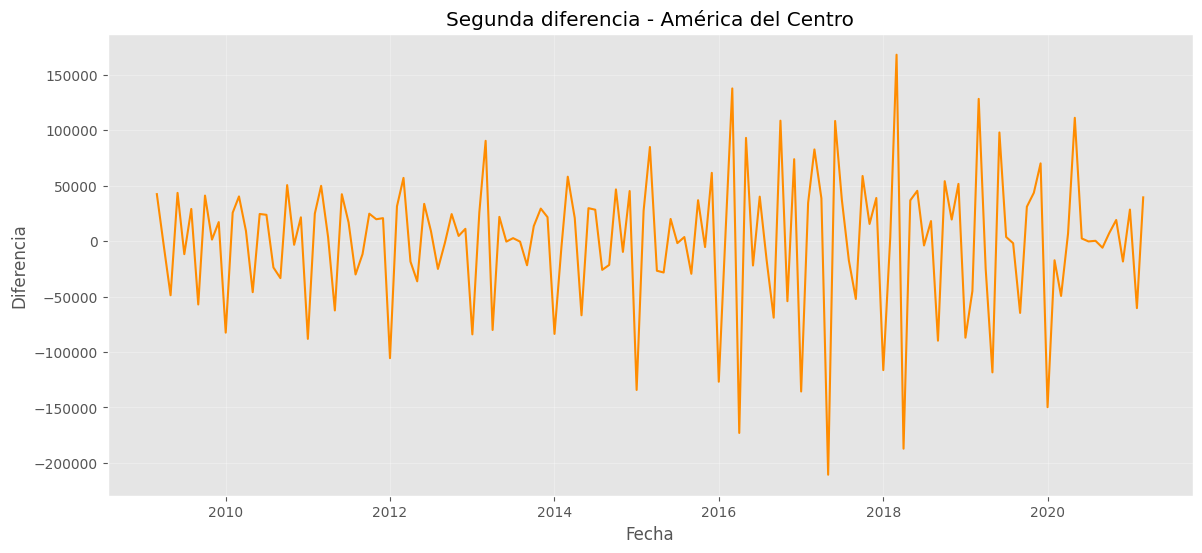

In [96]:
plt.figure(figsize=(14,6))

plt.plot(
    train_centro_diff2,
    color="darkorange"
)

plt.title("Segunda diferencia - América del Centro")

plt.xlabel("Fecha")
plt.ylabel("Diferencia")

plt.grid(alpha=0.3)

plt.show()

<Figure size 1000x500 with 0 Axes>

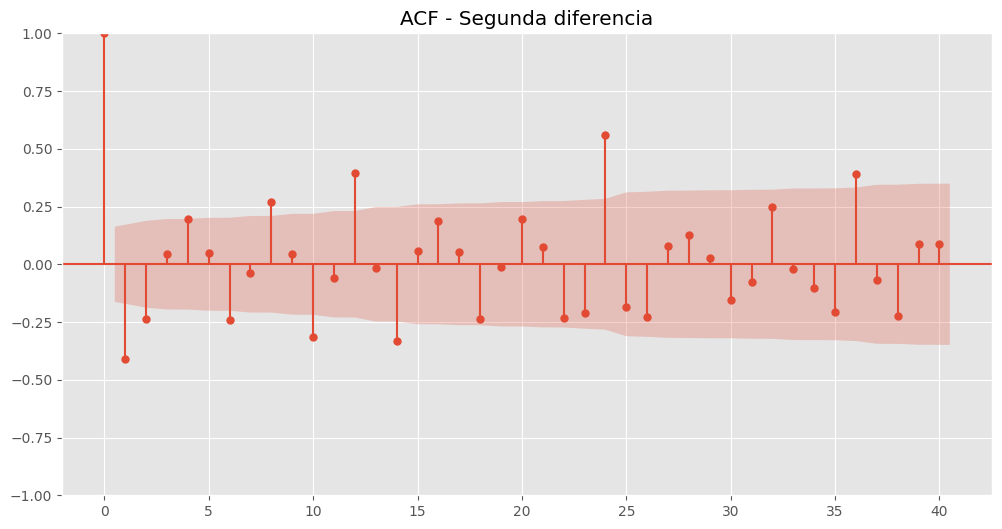

In [97]:
plt.figure(figsize=(10,5))

plot_acf(train_centro_diff2, lags=40)

plt.title("ACF - Segunda diferencia")

plt.show()

In [98]:
resultado_centro_diff2 = adfuller(train_centro_diff2)

print("ADF Statistic:", resultado_centro_diff2[0])
print("p-value:", resultado_centro_diff2[1])

print()

for key, value in resultado_centro_diff2[4].items():
    print(f"{key}: {value}")

ADF Statistic: -7.5089539877934826
p-value: 4.0635173679853445e-11

1%: -3.480500383888377
5%: -2.8835279559405045
10%: -2.578495716547007


# Conclusiones
## Conclusiones de la Serie Total

- La serie presenta una tendencia creciente hasta antes de la pandemia.
- Existe una estacionalidad anual claramente definida.
- La serie original no es estacionaria en media.
- Una primera diferenciación fue suficiente para hacer estacionaria la serie, por lo que se concluye que el parámetro de diferenciación es **d = 1**.

## Conclusiones de la Serie América del Centro

- La serie presenta una tendencia creciente y un comportamiento estacional similar al observado en la serie total.
- La pandemia produjo una disminución abrupta en el número de viajeros provenientes de América del Centro.
- La serie original no fue estacionaria en media.
- Después de aplicar una primera diferenciación, la serie continuó sin cumplir el criterio de estacionariedad.
- Fue necesaria una segunda diferenciación para obtener una serie estacionaria, por lo que el parámetro de diferenciación es **d = 2**.

# Conclusiones Generales

En el análisis exploratorio se observó que el ingreso de turistas y excursionistas a Guatemala presenta una tendencia creciente hasta el año 2020, además de un patrón estacional que se repite de manera anual. La pandemia de COVID-19 produjo una disminución abrupta del flujo de viajeros, seguida de una recuperación gradual en los años posteriores.

El análisis de las series de tiempo mostró que tanto la serie correspondiente al total mensual de turistas y excursionistas como la serie de América del Centro presentan tendencia y estacionalidad, por lo que inicialmente no son estacionarias en media.

La prueba Dickey-Fuller Aumentada confirmó estos resultados. La serie total requirió una primera diferenciación para alcanzar estacionariedad (d = 1), mientras que la serie correspondiente a América del Centro necesitó dos diferenciaciones (d = 2).

Con estos resultados se concluye que ambas series están preparadas para la construcción de modelos de pronóstico, los cuales serán desarrollados en la siguiente etapa del laboratorio.